# Configurable Regressor Experiments

This notebook is organized so users can run experiments on their own data by editing only `CONFIG`.

Workflow:
1. Update paths and feature options in `CONFIG`.
2. Run all cells.
3. Check saved metrics/plots under `plots/<experiment_name>@pca<k>/`.


In [11]:
%matplotlib inline

import json
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from functools import reduce

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import xgboost as xgb
from catboost import CatBoostRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler


## Main Config

Configure json file to run experiments on a different dataset.


In [ ]:
config_path = 'configs/default.json'
with open(config_path, "r") as f:
    CONFIG = json.load(f)
CONFIG

{'seed': 42,
 'experiment_name': 'test',
 'test_size': 0.2,
 'scale_features': True,
 'permutation_repeats': 10,
 'save_dataset_snapshot': True,
 'save_mean_correlations': True,
 'save_best_correlations': False,
 'paths': {'raw_scores': 'scores/labels.csv',
  'scores': 'scores/fn_scores.csv',
  'features_root': 'features',
  'plots_root': 'plots'},
 'score_preparation': {'enabled': True,
  'method_column': 'method',
  'case_column': 'test_case',
  'score_column': 'score_norm',
  'method_map': {'pasd': 'PASD', 'supir': 'SUPIR', 'realesrgan': 'RealESRGAN'},
  'name_suffix': '.npy.gz'},
 'dataset': {'name_column': 'name',
  'score_column': 'scores',
  'sr_method_column': 'sr_method',
  'sr_filename_column': 'sr_filename',
  'filename_suffix': '.npy.gz',
  'group_segment_index': 1,
  'group_remove_suffix': '.npy.gz',
  'metadata_drop': ['sample_id',
   'sr_method',
   'sr_filename',
   'sr_path',
   'gt_path',
   'lr_path',
   'set_type']},
 'features': {'pca_n': 5,
  'include': ['nr', 'fr

## Helpers

These functions are reusable across experiments and datasets.


In [13]:
def deep_update(base: dict, updates: dict) -> dict:
    result = deepcopy(base)
    for key, value in updates.items():
        if isinstance(value, dict) and isinstance(result.get(key), dict):
            result[key] = deep_update(result[key], value)
        else:
            result[key] = value
    return result


def safe_corr(y_true, y_pred):
    y_true_arr = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred_arr = np.asarray(y_pred, dtype=float).reshape(-1)

    if y_true_arr.size < 2 or y_pred_arr.size < 2:
        return np.nan, np.nan
    if y_true_arr.size != y_pred_arr.size:
        raise ValueError(
            f"safe_corr received arrays with different lengths: "
            f"y_true={y_true_arr.size}, y_pred={y_pred_arr.size}"
        )

    if np.allclose(y_true_arr, y_true_arr[0]) or np.allclose(y_pred_arr, y_pred_arr[0]):
        return np.nan, np.nan

    return (
        pearsonr(y_pred_arr, y_true_arr).statistic,
        spearmanr(y_pred_arr, y_true_arr).statistic,
    )


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def prepare_scores_file(cfg: dict) -> pd.DataFrame:
    prep_cfg = cfg["score_preparation"]
    raw_scores = pd.read_csv(cfg["paths"]["raw_scores"])

    method_col = prep_cfg["method_column"]
    case_col = prep_cfg["case_column"]
    score_col = prep_cfg["score_column"]

    method_map = {str(k).lower(): v for k, v in prep_cfg["method_map"].items()}
    mapped_methods = raw_scores[method_col].astype(str).str.lower().map(method_map)

    if mapped_methods.isna().any():
        missing = sorted(raw_scores.loc[mapped_methods.isna(), method_col].astype(str).unique().tolist())
        raise ValueError(f"Missing method_map entries for: {missing}")

    suffix = prep_cfg["name_suffix"]
    names = mapped_methods.astype(str) + "/" + raw_scores[case_col].astype(str) + suffix
    prepared = pd.DataFrame({
        "name": names,
        cfg["dataset"]["score_column"]: raw_scores[score_col],
    })

    score_path = Path(cfg["paths"]["scores"])
    ensure_dir(score_path.parent)
    prepared.to_csv(score_path, index=False)
    return prepared


def load_scores(cfg: dict) -> pd.DataFrame:
    if cfg["score_preparation"]["enabled"]:
        scores = prepare_scores_file(cfg)
    else:
        scores = pd.read_csv(cfg["paths"]["scores"])

    name_col = cfg["dataset"]["name_column"]
    score_col = cfg["dataset"]["score_column"]

    if name_col not in scores.columns:
        raise ValueError(f"Scores file must contain '{name_col}' column")

    if score_col not in scores.columns:
        fallback = [c for c in ["score", "scores", "mos", "mos_norm"] if c in scores.columns]
        if not fallback:
            raise ValueError(
                f"Scores file must contain '{score_col}' column. Available: {scores.columns.tolist()}"
            )
        scores = scores.rename(columns={fallback[0]: score_col})

    return scores[[name_col, score_col]].copy()


def build_sample_name(df: pd.DataFrame, cfg: dict) -> pd.Series:
    method_col = cfg["dataset"]["sr_method_column"]
    filename_col = cfg["dataset"]["sr_filename_column"]
    suffix = cfg["dataset"]["filename_suffix"]

    if method_col not in df.columns or filename_col not in df.columns:
        raise ValueError(
            f"Feature file must have '{method_col}' and '{filename_col}' columns. "
            f"Got: {df.columns.tolist()}"
        )

    stem = df[filename_col].astype(str).str.rsplit('.', n=1).str[0]
    return df[method_col].astype(str) + "/" + stem + suffix


def resolve_feature_path(feat_name: str, cfg: dict) -> Path:
    templates = cfg["features"]["feature_files"]
    if feat_name not in templates:
        raise KeyError(f"No path template configured for feature '{feat_name}'")

    template = templates[feat_name]
    path = template.format(
        features_root=cfg["paths"]["features_root"],
        pca_n=cfg["features"]["pca_n"],
    )
    return Path(path)


def keep_requested_fr_columns(df: pd.DataFrame, refs: list[str]) -> pd.DataFrame:
    refs_lower = [r.lower() for r in refs]
    keep_cols = ["name"]
    for col in df.columns:
        if col == "name":
            continue
        cl = col.lower()
        if any(cl.endswith("_" + ref) for ref in refs_lower):
            keep_cols.append(col)
    return df[keep_cols]


def load_feature_block(feat_name: str, cfg: dict, valid_names: set[str]) -> pd.DataFrame:
    path = resolve_feature_path(feat_name, cfg)
    if not path.exists():
        raise FileNotFoundError(f"Feature file for '{feat_name}' not found: {path}")

    df = pd.read_csv(path)
    df["name"] = build_sample_name(df, cfg)

    drop_candidates = cfg["dataset"]["metadata_drop"]
    drop_existing = [c for c in drop_candidates if c in df.columns]
    if drop_existing:
        df = df.drop(columns=drop_existing)

    if feat_name == "fr":
        df = keep_requested_fr_columns(df, cfg["features"]["fr_refs"])

    df = df[df["name"].isin(valid_names)].copy()
    return df


def load_stats_block(cfg: dict, valid_names: set[str]) -> pd.DataFrame:
    stats_path = resolve_feature_path("stats", cfg)
    if not stats_path.exists():
        raise FileNotFoundError(f"Stats file not found: {stats_path}")

    stats = pd.read_csv(stats_path)
    requested = ["name"] + cfg["features"]["stats_columns"]
    missing = [c for c in requested if c not in stats.columns]
    if missing:
        raise ValueError(f"Stats file is missing requested columns: {missing}")

    stats = stats[requested]
    stats = stats[stats["name"].isin(valid_names)].copy()
    return stats


def build_dataset(cfg: dict) -> pd.DataFrame:
    scores = load_scores(cfg)
    valid_names = set(scores[cfg["dataset"]["name_column"]].tolist())

    frames = [scores]

    if cfg["features"]["include_stats"]:
        frames.append(load_stats_block(cfg, valid_names))

    for feat_name in cfg["features"]["include"]:
        frames.append(load_feature_block(feat_name, cfg, valid_names))

    dataset = reduce(lambda left, right: pd.merge(left, right, on="name", how="inner"), frames)

    exclude_cols = cfg["features"]["exclude_columns"]
    existing_excludes = [c for c in exclude_cols if c in dataset.columns]
    if existing_excludes:
        dataset = dataset.drop(columns=existing_excludes)

    dataset = dataset.sort_values("name").reset_index(drop=True)
    return dataset


def build_group_keys(names: pd.Series, cfg: dict) -> pd.Series:
    segment_idx = cfg["dataset"]["group_segment_index"]
    remove_suffix = cfg["dataset"].get("group_remove_suffix", "")

    def one_name_to_group(value: str) -> str:
        parts = str(value).split("/")
        if len(parts) > segment_idx:
            key = parts[segment_idx]
        else:
            key = Path(value).name
        if remove_suffix and key.endswith(remove_suffix):
            key = key[: -len(remove_suffix)]
        return key

    return names.map(one_name_to_group)


def split_dataset(dataset: pd.DataFrame, cfg: dict):
    y = dataset[cfg["dataset"]["score_column"]]
    X = dataset.drop(columns=[cfg["dataset"]["name_column"], cfg["dataset"]["score_column"]])

    groups = build_group_keys(dataset[cfg["dataset"]["name_column"]], cfg)
    splitter = GroupShuffleSplit(n_splits=1, test_size=cfg["test_size"], random_state=cfg["seed"])
    train_idx, test_idx = next(splitter.split(dataset, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    if cfg["scale_features"]:
        scaler = MinMaxScaler()
        X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
        X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

    return X_train, X_test, y_train, y_test


def feature_family(feature_name: str) -> str:
    f = feature_name.lower()
    if any(x in f for x in ["musiq", "arniqa", "qalign", "unique", "paq2piq"]):
        return "NR"
    if any(f.endswith("_" + ref) for ref in ["gt", "bicubic", "span", "rlfn"]):
        return "FR"
    if f.startswith("vgg_"):
        return "VGG"
    if f.startswith("resnet_"):
        return "ResNet"
    if f in {"content_fidelity", "perceptual_enhancement", "final_rr_score"}:
        return "SigLIP"
    if f in {"min", "max", "mean", "median", "std", "p05", "p95", "area00", "area05", "area075"}:
        return "Stats"
    return "Other"


def importance_palette() -> dict[str, str]:
    return {
        "NR": "#ff6150",
        "FR": "#f8aa4b",
        "VGG": "#54d2d2",
        "ResNet": "#0e4a95",
        "SigLIP": "#5255ea",
        "Stats": "#5bea52",
        "Other": "#000000",
    }


def importance_legend_labels() -> dict[str, str]:
    return {
        "NR": "NR metrics",
        "FR": "FR metrics",
        "VGG": "VGG features",
        "ResNet": "ResNet features",
        "SigLIP": "SigLIP features",
        "Stats": "Artifact statistics",
        "Other": "Other",
    }


def init_models(cfg: dict):
    models_cfg = cfg["models"]
    seed = cfg["seed"]

    models = []

    if models_cfg.get("randomforest", {}).get("enabled", False):
        params = {"random_state": seed}
        params.update(models_cfg["randomforest"].get("params", {}))
        models.append(("randomforest", RandomForestRegressor(**params)))

    if models_cfg.get("xgb", {}).get("enabled", False):
        params = {"random_state": seed, "verbosity": 0}
        params.update(models_cfg["xgb"].get("params", {}))
        models.append(("xgb", xgb.XGBRegressor(**params)))

    if models_cfg.get("catboost", {}).get("enabled", False):
        params = {"random_state": seed, "verbose": 0}
        params.update(models_cfg["catboost"].get("params", {}))
        models.append(("catboost", CatBoostRegressor(**params)))

    if not models:
        raise ValueError("No models are enabled in CONFIG['models']")

    return models


def plot_importance(model_name: str, model, X_test: pd.DataFrame, y_test: pd.Series, out_dir: Path, cfg: dict):
    if not hasattr(model, "feature_importances_"):
        return None

    importances = pd.Series(model.feature_importances_, index=X_test.columns).sort_values(ascending=True)
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=cfg["permutation_repeats"],
        random_state=cfg["seed"],
        n_jobs=2,
    )

    palette = importance_palette()
    colors = [palette[feature_family(name)] for name in importances.index]

    fig, ax = plt.subplots(figsize=tuple(cfg["plot"]["importance_figsize"]))
    importances.plot.barh(yerr=perm.importances_std, ax=ax, color=colors)
    ax.set_title(f"Feature Importances: {model_name}")
    ax.set_xlabel("Importance")
    fig.tight_layout()

    out_path = out_dir / f"importance_{model_name}.png"
    fig.savefig(out_path)
    plt.close(fig)
    return out_path


def plot_all_importances(importance_paths: dict[str, str | None], out_dir: Path, cfg: dict):
    valid = []
    for model_name, path in importance_paths.items():
        if path is None:
            continue
        p = Path(path)
        if p.exists():
            valid.append((model_name, p))

    if not valid:
        return None

    images = [plt.imread(path) for _, path in valid]
    n = len(images)

    single_w, single_h = tuple(cfg["plot"]["importance_figsize"])
    fig, axes = plt.subplots(1, n, figsize=(single_w * n, single_h))

    if n == 1:
        axes = [axes]

    for ax, (model_name, _), image in zip(axes, valid, images):
        ax.imshow(image)
        # ax.set_title(model_name)
        ax.axis("off")

    palette = importance_palette()
    labels = importance_legend_labels()
    handles = [mpatches.Patch(color=palette[key], label=labels[key]) for key in labels]

    fig.legend(handles=handles, loc="center right", bbox_to_anchor=(0.995, 0.5))
    fig.tight_layout(rect=(0, 0, 0.9, 1))

    out_path = out_dir / "all_models_importances.png"
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    return out_path


def plot_correlations(results_df: pd.DataFrame, out_dir: Path, cfg: dict):
    df = results_df.sort_values("srcc", ascending=False).reset_index(drop=True)

    bar_width = 0.18
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=tuple(cfg["plot"]["correlation_figsize"]))
    ax.bar(x - bar_width / 2, df["plcc"], width=bar_width, label="PLCC", color="#845ec2")
    ax.bar(x + bar_width / 2, df["srcc"], width=bar_width, label="SRCC", color="#00c9a7")
    ax.set_xticks(x)
    ax.set_xticklabels(df["model"].tolist())
    ax.set_ylim(0, 1)
    ax.set_ylabel("Correlation")
    ax.set_title("Model Correlation Scores")
    ax.legend(loc="upper right")
    fig.tight_layout()

    out_path = out_dir / "correlations.png"
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    return out_path


def run_experiment(cfg: dict) -> dict:
    np.random.seed(cfg["seed"])

    dataset = build_dataset(cfg)
    X_train, X_test, y_train, y_test = split_dataset(dataset, cfg)

    run_name = f"{cfg['experiment_name']}@pca{cfg['features']['pca_n']}"
    out_dir = ensure_dir(Path(cfg["paths"]["plots_root"]) / run_name)

    if cfg.get("save_dataset_snapshot", False):
        dataset.to_csv(out_dir / "dataset_snapshot.csv", index=False)

    results = []
    importance_paths = {}

    all_plcc, all_srcc = [], []

    for model_name, model in init_models(cfg):
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        plcc, srcc = safe_corr(y_test, pred)
        all_plcc.append(plcc)
        all_srcc.append(srcc)

        results.append({"model": model_name, "plcc": plcc, "srcc": srcc})
        imp_path = plot_importance(model_name, model, X_test, y_test, out_dir, cfg)
        importance_paths[model_name] = str(imp_path) if imp_path else None
    
    if cfg['save_mean_correlations']:
        results.append({"model": "mean", "plcc": np.mean(all_plcc), "srcc": np.mean(all_srcc)})
    if cfg['save_best_correlations']:
        results.append({"model": "best", "plcc": np.max(all_plcc), "srcc": np.max(all_srcc)})

    results_df = pd.DataFrame(results).sort_values("srcc", ascending=False).reset_index(drop=True)
    results_df.to_csv(out_dir / "correlations.csv", index=False)
    combined_importance_path = plot_all_importances(importance_paths, out_dir, cfg)
    plot_correlations(results_df, out_dir, cfg)

    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    return {
        "dataset": dataset,
        "results": results_df,
        "output_dir": out_dir,
        "importance_paths": importance_paths,
        "all_importances_path": str(combined_importance_path) if combined_importance_path else None,
    }


## Run One Experiment

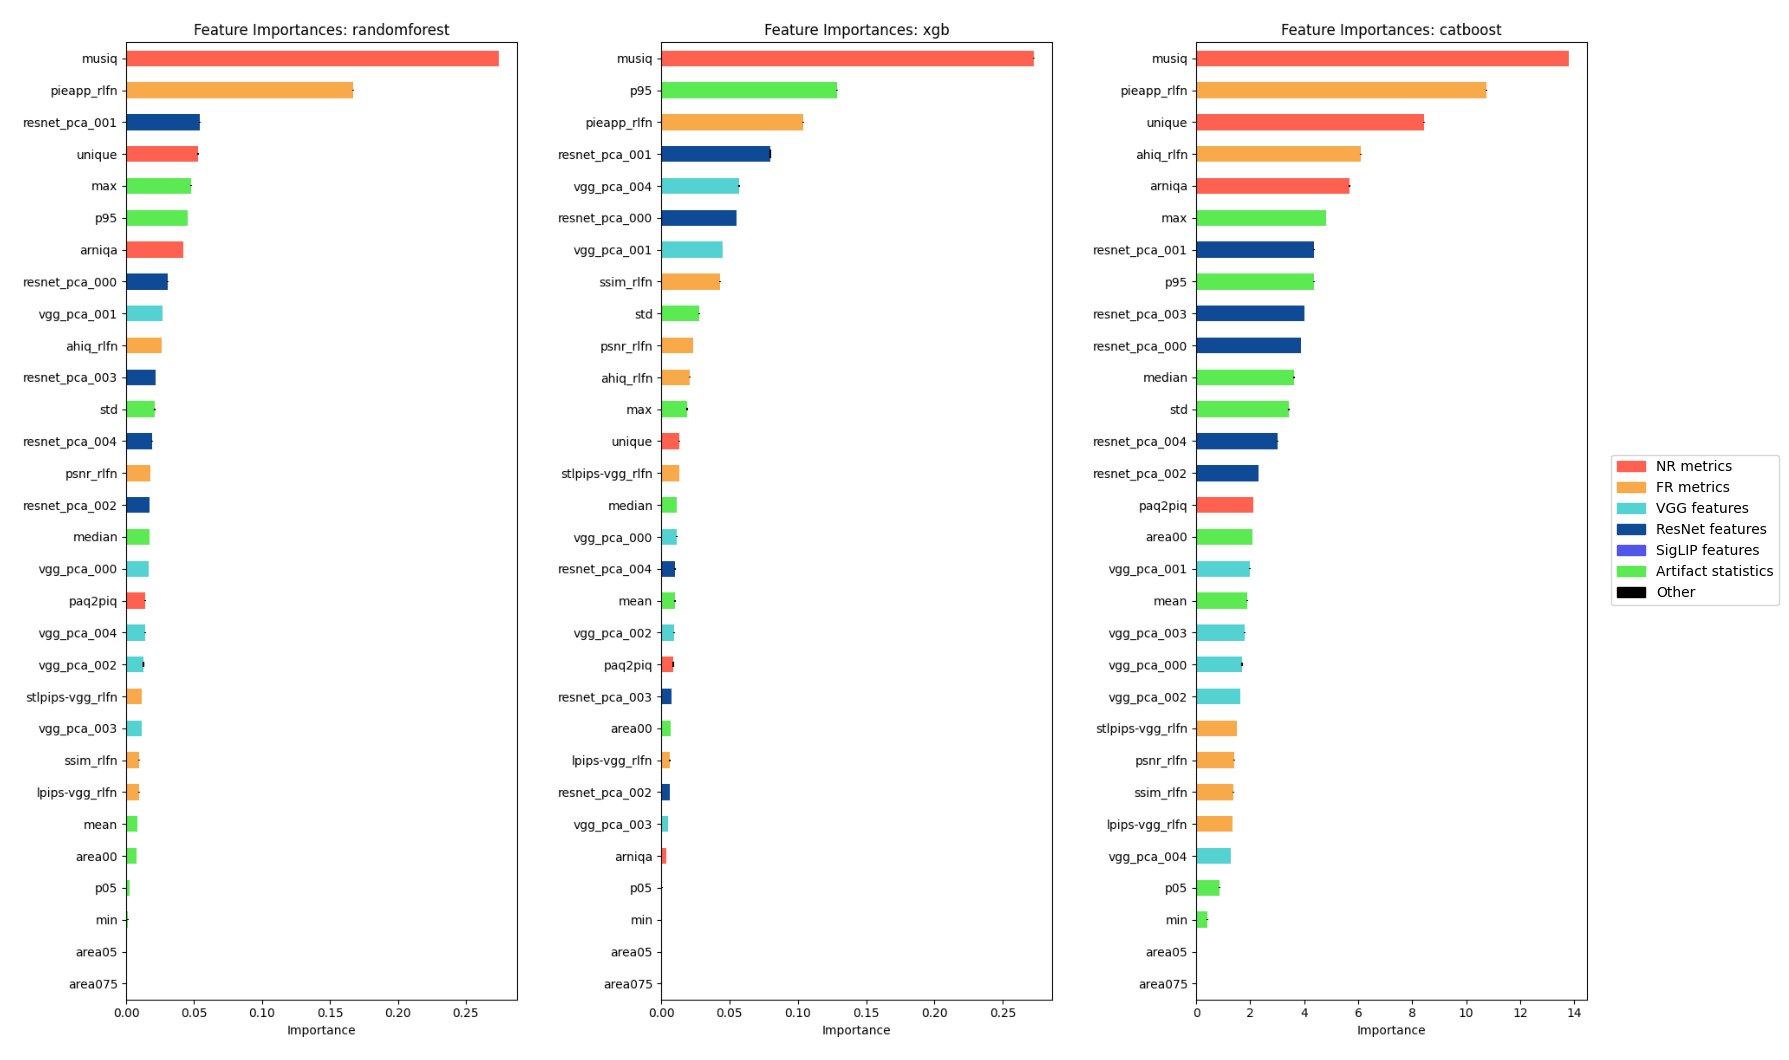

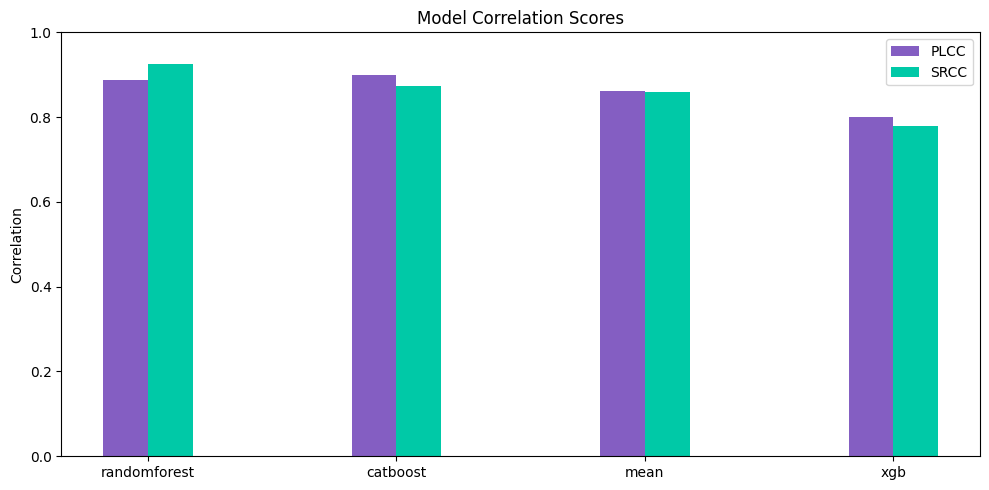

,model,plcc,srcc
0,randomforest,0.887251,0.926087
1,catboost,0.899049,0.873913
2,mean,0.862100,0.859710
3,xgb,0.799999,0.779130


In [14]:
run = run_experiment(CONFIG)
run["results"]


## Optional Batch Runs

Set overrides and run several experiments in one go.


In [15]:
# Override config loaded before
BATCH_OVERRIDES = [
    # {
    #     "experiment_name": "nr_only",
    #     "features": {
    #         "include": ["nr"],
    #         "include_stats": False,
    #     },
    # },
    # {
    #     "experiment_name": "fr_vgg_resnet",
    #     "features": {
    #         "include": ["fr", "vgg", "resnet"],
    #         "fr_refs": ["rlfn", "span"],
    #     },
    # },
]

# Launch alternate configs
CONFIG_FILES = [
    # "configs/default.json"
]

batch_results = []
for override in BATCH_OVERRIDES:
    cfg = deep_update(CONFIG, override)
    result = run_experiment(cfg)
    row = result["results"].copy()
    row.insert(0, "experiment", cfg["experiment_name"])
    batch_results.append(row)
for config_path in CONFIG_FILES:
    with open(config_path, "r") as f:
        cfg = json.load(f)
    result = run_experiment(cfg)
    row = result["results"].copy()
    row.insert(0, "experiment", cfg["experiment_name"])
    batch_results.append(row)

if batch_results:
    summary = pd.concat(batch_results, ignore_index=True)
    display(summary)
else:
    print("No batch overrides configured.")


No batch overrides configured.
